In [213]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

In [215]:
df_cluster = df_processed.groupby('country')[['asylum_per_100k', 'crime_per_100k']].mean()

In [ ]:
# 2b. Country-level means for asylum and each crime + PCA correlation plots

# Prepare matrix: mean per country over all years for asylum_per_100k and each ICCS crime code
crime_cols = list(crime_codes.keys())
cols_pca = ['asylum_per_100k'] + crime_cols

df_country_means = (
    df_processed
    .groupby('country')[cols_pca]
    .mean()
    .dropna()
 )

import numpy as np
from sklearn.decomposition import PCA

X = df_country_means.values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Plot 1: countries in PCA space
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=20)
for i, country in enumerate(df_country_means.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], country, fontsize=7)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.xlabel(f'PC1 ({pc1_var:.1f}% var)')
plt.ylabel(f'PC2 ({pc2_var:.1f}% var)')
plt.title('Countries in PCA space (asylum_per_100k + crime codes)')
plt.tight_layout()
plt.show()

# Plot 2: PCA "correlation circle" showing loadings of each variable
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(6, 6))
ax = plt.gca()
circle = plt.Circle((0, 0), 1, color='lightgrey', fill=False, linestyle='--')
ax.add_artist(circle)

for i, col in enumerate(cols_pca):
    x, y = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x * 0.95, y * 0.95, head_width=0.03, head_length=0.03, fc='red', ec='red')
    ax.text(x * 1.05, y * 1.05, col, fontsize=8)

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading')
ax.set_ylabel('PC2 loading')
ax.set_title('PCA correlation circle: asylum_per_100k & crime codes')
ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

In [216]:
# 2. K-Means: asylum applications per country (mean per 100k)

# Standardize the feature and run 1D K-Means on asylum_per_100k
scaler_asylum = StandardScaler()
X_asylum = scaler_asylum.fit_transform(df_cluster[['asylum_per_100k']])

k = 6
kmeans_asylum = KMeans(n_clusters=k, random_state=42)
df_cluster['cluster_asylum_raw'] = kmeans_asylum.fit_predict(X_asylum)

# Reorder labels so 0 = lowest mean asylum_per_100k, 4 = highest
means_asylum = (
    df_cluster
    .groupby('cluster_asylum_raw')['asylum_per_100k']
    .mean()
    .sort_values()
 )
label_map_asylum = {old: new for new, old in enumerate(means_asylum.index)}
df_cluster['cluster_asylum'] = df_cluster['cluster_asylum_raw'].map(label_map_asylum)

# Inspect a few rows
df_cluster[['asylum_per_100k', 'cluster_asylum']].head()

,asylum_per_100k,cluster_asylum
country,,
Austria,437.005959,5
Belgium,175.247343,2
Bulgaria,145.937788,2
Croatia,33.136121,0
Czechia,10.525457,0


In [217]:
# 3. K-Means: total crime per country (mean per 100k)

# Standardize the feature and run 1D K-Means on crime_per_100k
scaler_crime = StandardScaler()
X_crime = scaler_crime.fit_transform(df_cluster[['crime_per_100k']])

k = 6
kmeans_crime = KMeans(n_clusters=k, random_state=42)
df_cluster['cluster_crime_raw'] = kmeans_crime.fit_predict(X_crime)

# Reorder labels so 0 = lowest mean crime_per_100k, 4 = highest
means_crime = (
    df_cluster
    .groupby('cluster_crime_raw')['crime_per_100k']
    .mean()
    .sort_values()
 )
label_map_crime = {old: new for new, old in enumerate(means_crime.index)}
df_cluster['cluster_crime'] = df_cluster['cluster_crime_raw'].map(label_map_crime)

# Optional: compare how many countries fall into each ordered cluster
print('Asylum clusters (ordered) value counts:')
print(df_cluster['cluster_asylum'].value_counts().sort_index())

print('\nCrime clusters (ordered) value counts:')
print(df_cluster['cluster_crime'].value_counts().sort_index())

Asylum clusters (ordered) value counts:
cluster_asylum
0    9
1    6
2    5
3    2
4    3
5    2
Name: count, dtype: int64

Crime clusters (ordered) value counts:
cluster_crime
0    13
1     4
2     3
3     3
4     2
5     2
Name: count, dtype: int64


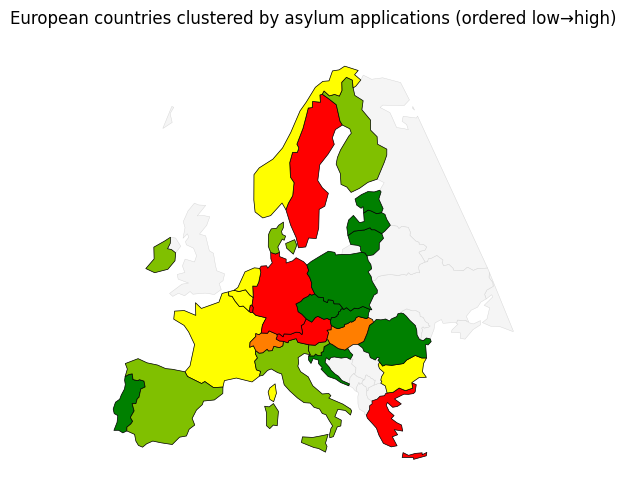

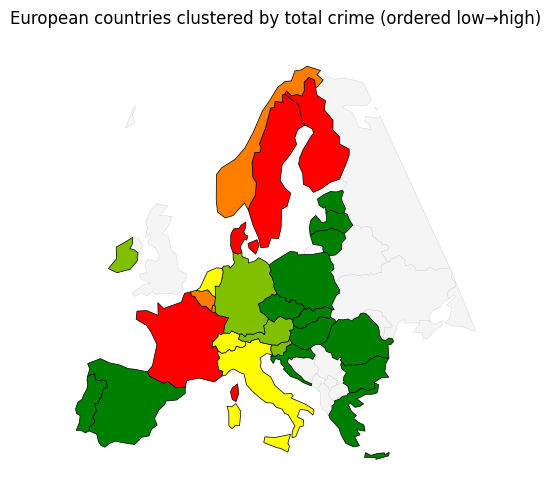

In [218]:
# 4. Plot maps of Europe for both clusterings (single vector source with light background and ordered clusters)

import geopandas as gpd
from shapely.geometry import box
from matplotlib.colors import LinearSegmentedColormap

# URL to Natural Earth admin-0 countries (110m resolution)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Load world country borders
world = gpd.read_file(url)

# Filter to Europe by continent
europe = world[world["CONTINENT"] == "Europe"].copy()

# Define Europe bounding box (lon/lat) and clip geometries
europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

# Merge your cluster data
df_cluster_reset = df_cluster.reset_index()
gdf = europe.merge(
    df_cluster_reset,
    left_on="NAME",   # Natural Earth uses "NAME" for country names
    right_on="country",
    how="left"
)

# Reproject to a Europe-friendly projected CRS (ETRS89 / LAEA Europe)
gdf_laea = gdf.to_crs(epsg=3035)

# Define a green→red colormap for ordered clusters 0..4
cluster_cmap = LinearSegmentedColormap.from_list("green_red", ["green", "yellow", "red"])

# Map 1: clusters based on asylum applicants per 100k
fig, ax = plt.subplots(figsize=(7, 5))
# light background for all European countries
gdf_laea.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)
# overlay only countries with asylum clusters
gdf_laea.dropna(subset=["cluster_asylum"]).plot(
    column="cluster_asylum",
    ax=ax,
    cmap=cluster_cmap,
    vmin=0,
    vmax=4,
    edgecolor="black",
    linewidth=0.5,
    legend=False
)
ax.set_title("European countries clustered by asylum applications (ordered low→high)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Map 2: clusters based on crime rate per 100k
fig, ax = plt.subplots(figsize=(7, 5))
# light background for all European countries
gdf_laea.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)
# overlay only countries with crime clusters
gdf_laea.dropna(subset=["cluster_crime"]).plot(
    column="cluster_crime",
    ax=ax,
    cmap=cluster_cmap,
    vmin=0,
    vmax=4,
    edgecolor="black",
    linewidth=0.5,
    legend=False
)
ax.set_title("European countries clustered by total crime (ordered low→high)")
ax.set_axis_off()
plt.tight_layout()
plt.show()